# REGRESIÓN LOGISTICA MULTICLASE PARA CLASIFICACIÓN DE FRIJOLES
## FUENTE : [KAGGLE](https://www.kaggle.com/datasets/sansuthi/dry-bean-dataset)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_4\Dry_Bean.csv")
df.head(5)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


# EDA Y TRATAMIENTO DE DATOS FALTANTES Y DUPLICADOS

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [30]:
df.dtypes.value_counts()

float64    14
int64       2
object      1
dtype: int64

In [31]:
df['Class'].unique()

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [32]:
df.isna().sum().sum()

0

In [33]:
df.duplicated().sum()

68

In [34]:
df.shape

(13611, 17)

In [35]:
df.drop_duplicates(inplace=True)

In [36]:
df.shape

(13543, 17)

# UNDERSAMPLING

In [42]:
print(df.columns)

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')


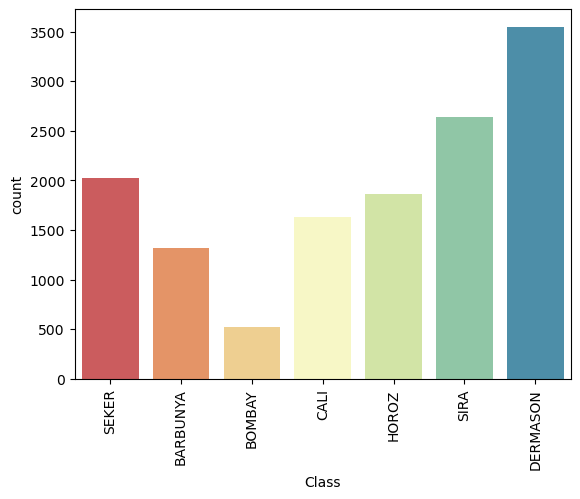

In [55]:
sns.countplot(x=df['Class'],palette="Spectral")
plt.xticks(rotation=90)
plt.show()

## RandomUnderSampler (Submuestreo Aleatorio) en Python
El RandomUnderSampler es una técnica de submuestreo utilizada para equilibrar conjuntos de datos desbalanceados eliminando instancias de la clase mayoritaria de forma aleatoria.

📌 ¿Cuándo usarlo?
Cuando tienes un conjunto de datos desbalanceado (una clase con muchas más instancias que otra) y quieres reducir el número de muestras de la clase mayoritaria para equilibrar la distribución.

|Método	|Cuándo usarlo|
| :---        |            :--- |
|Submuestreo (RandomUnderSampler)|	Cuando la clase mayoritaria es muy grande y no quieres aumentar datos artificialmente.|
|Sobremuestreo (SMOTE, RandomOverSampler)|	Cuando la clase minoritaria es demasiado pequeña y no quieres perder datos de| la clase mayoritaria.

In [56]:
from imblearn.under_sampling import RandomUnderSampler
undersample = RandomUnderSampler(random_state=42)

In [57]:
X = df.drop('Class',axis=1)
y = df['Class']

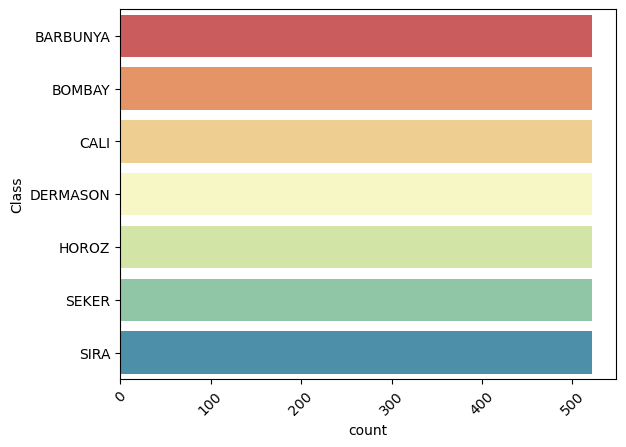

In [59]:
X_over,y_over = undersample.fit_resample(X,y)
sns.countplot(y=y_over,palette="Spectral")
plt.xticks(rotation=45)
plt.show()

In [68]:
df.shape

(13543, 17)

# CODIFICACIÓN DE VARIABLES CATEGORICAS

In [69]:
list(np.unique(y_over))

['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

In [70]:
y_over.replace(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],[1,2,3,4,5,6,7],inplace=True)
list(np.unique(y_over))

[1, 2, 3, 4, 5, 6, 7]

In [71]:
df_corr = X_over
df_corr['Class'] = y_over
df_corr

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,70776,1060.894,386.619944,234.100208,1.651515,0.795842,71978,300.191276,0.775763,0.983300,0.790227,0.776451,0.005463,0.001225,0.602875,0.995658,1
1,66370,1004.139,339.287072,249.883085,1.357783,0.676443,67637,290.697280,0.720536,0.981268,0.827169,0.856789,0.005112,0.001699,0.734087,0.996731,1
2,60736,985.501,342.445302,226.741775,1.510288,0.749393,61680,278.085377,0.789353,0.984695,0.785854,0.812058,0.005638,0.001512,0.659438,0.995941,1
3,65219,1011.110,353.650546,235.308999,1.502920,0.746512,66672,288.165594,0.719436,0.978207,0.801654,0.814831,0.005423,0.001475,0.663950,0.997864,1
4,51332,889.637,330.822804,198.618899,1.665616,0.799716,52283,255.651975,0.751688,0.981811,0.815028,0.772776,0.006445,0.001418,0.597183,0.994678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,44358,785.631,288.303275,196.970714,1.463686,0.730225,44898,237.651761,0.791937,0.987973,0.903118,0.824312,0.006499,0.001851,0.679490,0.994560,7
3650,37641,742.538,284.313737,169.740814,1.674987,0.802227,38112,218.920099,0.744187,0.987642,0.857894,0.769995,0.007553,0.001638,0.592892,0.993087,7
3651,40668,747.000,271.731569,191.687622,1.417575,0.708780,41257,227.552424,0.712162,0.985724,0.915844,0.837416,0.006682,0.002027,0.701266,0.994097,7
3652,53233,893.511,329.969126,206.375684,1.598876,0.780273,54022,260.342775,0.689154,0.985395,0.837898,0.788991,0.006199,0.001482,0.622507,0.995312,7


# CORRELACIONES

In [72]:
corr_matrix = df_corr.corr()
corr_class = corr_matrix['Class']
corr_class.sort_values(ascending=False)

Class              1.000000
ShapeFactor1       0.595998
ShapeFactor2       0.493776
roundness          0.436332
Solidity           0.320507
ShapeFactor4       0.202544
ShapeFactor3       0.177881
Compactness        0.160470
Extent            -0.084210
AspectRation      -0.100902
Eccentricity      -0.227830
Area              -0.566347
ConvexArea        -0.568049
MinorAxisLength   -0.583856
MajorAxisLength   -0.584255
EquivDiameter     -0.601721
Perimeter         -0.630055
Name: Class, dtype: float64

<Axes: >

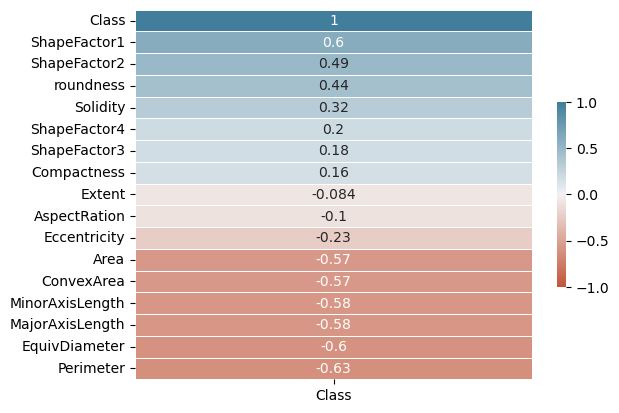

In [73]:

sns.heatmap(
    data=corr_class.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [74]:
corr_filtered = corr_class[corr_class > 0]
cols = corr_filtered.index.tolist()
cols

['Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3',
 'ShapeFactor4',
 'Class']

# ENTRENAMIENTO DEL MODELO

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,ConfusionMatrixDisplay

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X_over,y_over,random_state=42,shuffle=True,test_size=0.2)

# ESTRATEGIAS PARA MANEJAR PROBLEMAS DE CLASIFICACIÓN MULTICLASE

* OVER(ONE VS REST) : esta estrategia entrena un clasificador binario por cada clase.
* multinomial : rata todas las clases al mismo tiempo en un solo modelo de clasificación multiclase.

In [77]:
model_ovr = LogisticRegression(multi_class='ovr',solver='lbfgs',max_iter=500)
model_ovr.fit(X_train,y_train)
y_pred_ovr = model_ovr.predict(X_test)
print(f"Ovr Accuracy : {accuracy_score(y_test,y_pred_ovr)}")

Ovr Accuracy : 0.9863201094391245


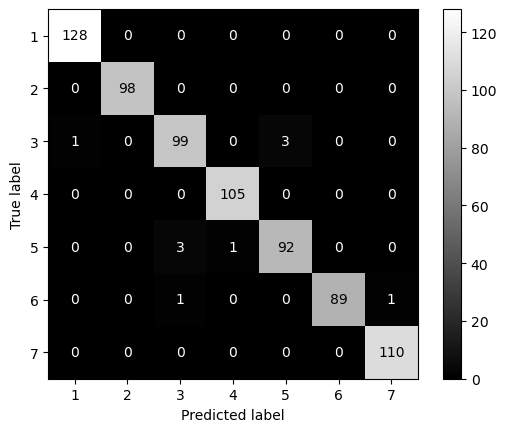

In [78]:
cm = confusion_matrix(y_test,y_pred_ovr,labels=model_ovr.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_ovr.classes_)
disp.plot(cmap='gray')
plt.show()

In [79]:
model_multinomial = LogisticRegression(multi_class='multinomial',solver='lbfgs',max_iter=500)
model_multinomial.fit(X_train,y_train)
y_pred_multinomial = model_multinomial.predict(X_test)
print(f"Ovr Multinomial : {accuracy_score(y_test,y_pred_multinomial)}")

Ovr Multinomial : 0.8495212038303693


C:\Users\ingma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


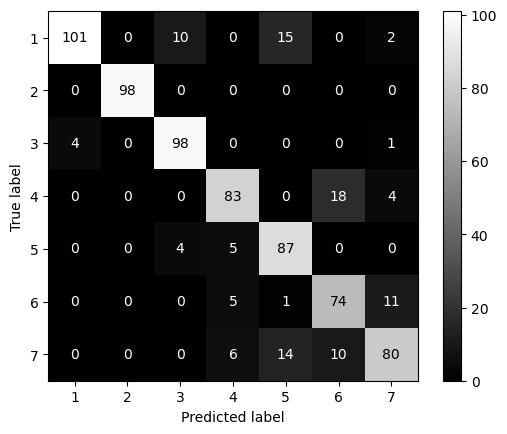

In [80]:
cm = confusion_matrix(y_test,y_pred_multinomial,labels=model_multinomial.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_multinomial.classes_)
disp.plot(cmap='gray')
plt.show()

# COMPARAMOS DISTINTOS PARAMETROS

In [81]:
multiclass = ['ovr','multinomial']
solver_list = ['newton-cg','lbfgs','sag', 'saga']
scores = []
params = []

def logistic_model(C_,solver_,multiclass_):
  logistic_regression_model = LogisticRegression(random_state=42,solver=solver_,multi_class=multiclass_,n_jobs=-1,C=C_)
  return logistic_regression_model

for i in multiclass:
  for j in solver_list:
    try:
      model = logistic_model(1,j,i)
      model.fit(X_train,y_train)
      predictions = model.predict(X_test)
      params.append(i + '-' + j)
      accuraccy = accuracy_score(y_test,predictions)
      scores.append(accuraccy)
    except:
      None

C:\Users\ingma\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ingma\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ingma\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\ingma\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'ovr-newton-cg'),
  Text(1, 0, 'ovr-lbfgs'),
  Text(2, 0, 'ovr-sag'),
  Text(3, 0, 'ovr-saga'),
  Text(4, 0, 'multinomial-newton-cg'),
  Text(5, 0, 'multinomial-lbfgs'),
  Text(6, 0, 'multinomial-sag'),
  Text(7, 0, 'multinomial-saga')])

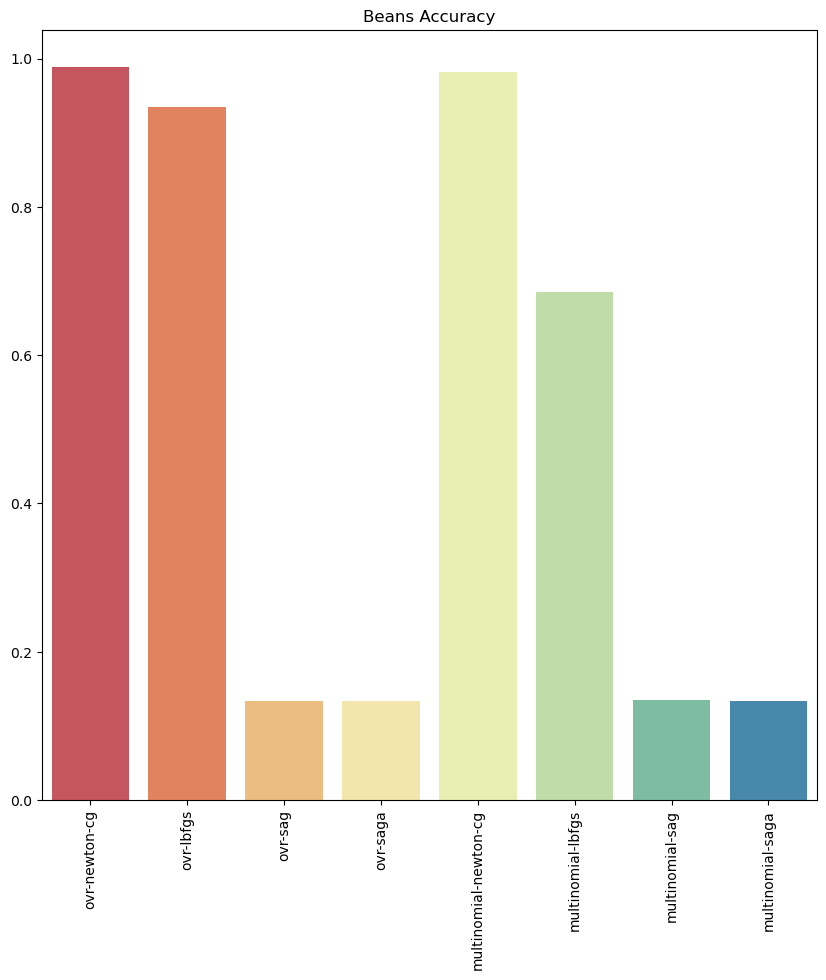

In [88]:
fig = plt.figure(figsize=(10,10))
sns.barplot(x=params,y=scores,palette="Spectral").set_title('Beans Accuracy')
plt.xticks(rotation=90)

## Ejemplo Under Sampler , Balanceado

In [67]:
import pandas as pd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Datos de ejemplo
X = pd.DataFrame({'feature1': np.random.rand(100), 'feature2': np.random.rand(100)})
y = np.concatenate((np.zeros(80), np.ones(20)))  # Clase 0 = 900 muestras, Clase 1 = 100 muestras
display(X)
display(y)
print("Distribución antes del submuestreo:", Counter(y))

rus = RandomUnderSampler(random_state=42)  # Inicializa el submuestreo
X_resampled, y_resampled = rus.fit_resample(X, y)  # Aplica el submuestreo

print("Distribución después del submuestreo:", Counter(y_resampled))

,feature1,feature2
0,0.303542,0.470355
1,0.715930,0.422774
2,0.542811,0.664183
3,0.329812,0.728942
4,0.921612,0.410973
...,...,...
95,0.798028,0.543762
96,0.760388,0.437451
97,0.591970,0.755306
98,0.558314,0.101259


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Distribución antes del submuestreo: Counter({0.0: 80, 1.0: 20})
Distribución después del submuestreo: Counter({0.0: 20, 1.0: 20})
